# Analyze Statistics of Nash Equilibria

In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [3]:
df = pickle.load(open('data/equilibrium_stats/haar_8442b552/eqdata_randstates_haar_combined.pkl', 'rb'))

In [4]:
df_NE = df[df['nash_equilibrium'] == True]
df_NE = df_NE.assign(welfare=df_NE['energy'].apply(np.sum))
df_NE = df_NE.assign(tot_expl=df_NE['expl'].apply(np.sum))
df_NE.sort_values(by='welfare', ascending=False, inplace=True)
df_NE[['welfare', 'tot_expl']].head()

,welfare,tot_expl
311,6.924730,0.000894
2903,6.882104,0.000957
2738,6.856156,0.000881
5159,6.847764,0.000951
166,6.835258,0.000968


In [5]:
df['state'].iloc[1].shape

(2, 2, 2)

In [ ]:
# For three qubits, the residual entropy is proportional to the hyperdeterminant

from solver import compute_ent_params_from_state
df_NE = df_NE.assign(ent_params=df_NE['state'].apply(compute_ent_params_from_state))
df_NE[['ent_params']].head()



Text(0.5, 1.0, 'Welfare vs Hyperdeterminant')

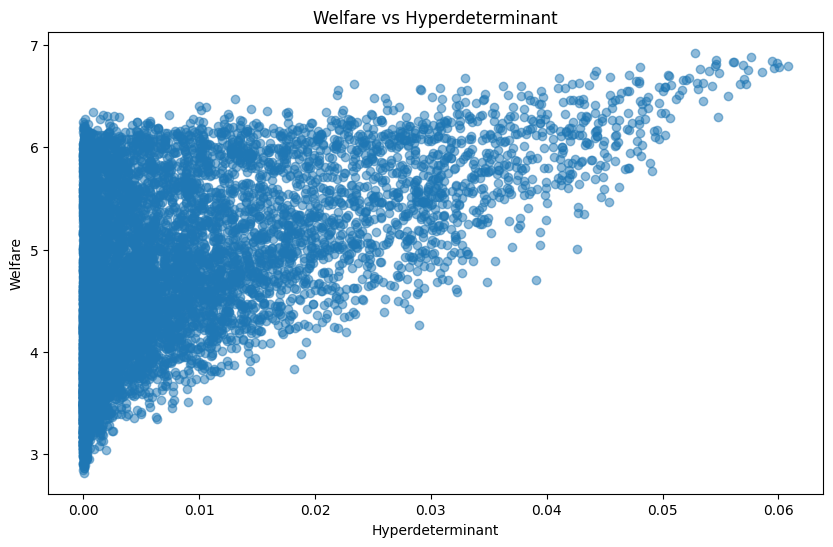

In [17]:
import matplotlib.pyplot as plt
X = df_NE['ent_params'].apply(lambda x: x[4]).to_numpy()
Y = df_NE['welfare'].to_numpy()
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5)
plt.xlabel('Hyperdeterminant')
plt.ylabel('Welfare')
plt.title('Welfare vs Hyperdeterminant')